<a href="https://colab.research.google.com/github/chiderakanu5-creator/TECHCRUSH-CAPSTONE-PROJECT/blob/main/Copy_of_Capstone_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Topic: Spam Email Classifiers

# 1. Import Necessary Libraries

In [31]:
import numpy as np
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

import nltk

!unzip /usr/share/nltk_data/corpora/wordnet.zip -d /usr/share/nltk_data/corpora/

from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

unzip:  cannot find or open /usr/share/nltk_data/corpora/wordnet.zip, /usr/share/nltk_data/corpora/wordnet.zip.zip or /usr/share/nltk_data/corpora/wordnet.zip.ZIP.


## 1.1. Import Dataset from Kaggle

In [6]:
df = pd.read_csv('/content/archive (4).zip')

# 2. Viewing Properties of Dataset

2.1 Vieing Shape of Dataframe
This shows that they are 2 columns and 5,559 rows in the data set.

In [7]:
df.shape

(5559, 2)

2.2. Dataset information;
This gives a summary of the information contained in the dataset as it concerns the number of entries, rows/columns, datatype, missing values etc

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5559 entries, 0 to 5558
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   type    5559 non-null   object
 1   text    5559 non-null   object
dtypes: object(2)
memory usage: 87.0+ KB


2.3 ;Dataset Preview - from head or tail:
This displays a range of the set, either from the top or bottome entries.

In [9]:
df.head(20)

,type,text
0,ham,Hope you are having a good week. Just checking in
1,ham,K..give back my thanks.
2,ham,Am also doing in cbe only. But have to pay.
3,spam,"complimentary 4 STAR Ibiza Holiday or £10,000 ..."
4,spam,okmail: Dear Dave this is your final notice to...
5,ham,Aiya we discuss later lar... Pick u up at 4 is...
6,ham,Are you this much buzy
7,ham,Please ask mummy to call father
8,spam,Marvel Mobile Play the official Ultimate Spide...
9,ham,"fyi I'm at usf now, swing by the room whenever"


In [10]:
df.tail()

,type,text
5554,ham,You are a great role model. You are giving so ...
5555,ham,"Awesome, I remember the last time we got someb..."
5556,spam,"If you don't, your prize will go to another cu..."
5557,spam,"SMS. ac JSco: Energy is high, but u may not kn..."
5558,ham,Shall call now dear having food


## 2.4 Describing the dataframe:
This gives the statistical analysis of the dataset where necessary.

In [11]:
df.describe()

,type,text
count,5559,5559
unique,2,5156
top,ham,"Sorry, I'll call later"
freq,4812,30


In [12]:
df.describe().T

,count,unique,top,freq
type,5559,2,ham,4812
text,5559,5156,"Sorry, I'll call later",30


# 3. Cleaning Dataset

## 3.1. Checking for Missing Values.
This show if there are missing enteries and the data type, whether it is a string, int, bollian or float.  

##

In [13]:
df.isnull().sum()

,0
type,0
text,0


## 3.2. Checking for Duplicate:
This checks if they are duplicate entries in the dataframe.
The output below shows that they are 403 uplicates in the entry and all are of the INT data type.

In [14]:
df.duplicated().sum()

np.int64(403)

## 3.2.1. After Dropping Duplicate.
On dropping 403 duplicated entries from the 5,559 entries, it remaining 5,156 rows arranged in 2 columns.

In [15]:
df.drop_duplicates()

,type,text
0,ham,Hope you are having a good week. Just checking in
1,ham,K..give back my thanks.
2,ham,Am also doing in cbe only. But have to pay.
3,spam,"complimentary 4 STAR Ibiza Holiday or £10,000 ..."
4,spam,okmail: Dear Dave this is your final notice to...
...,...,...
5554,ham,You are a great role model. You are giving so ...
5555,ham,"Awesome, I remember the last time we got someb..."
5556,spam,"If you don't, your prize will go to another cu..."
5557,spam,"SMS. ac JSco: Energy is high, but u may not kn..."


# 4. Trainig the Dataset
This generates a Random Forec classifier, using the training data into X train (Training_input_data) and y train (Training_output_data), which will them make prediction on the data.

In [16]:
vectorizer = TfidfVectorizer(stop_words="english", lowercase=True)
X = pd.DataFrame(vectorizer.fit_transform(df["text"]).toarray())
y = df["type"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
clf = RandomForestClassifier(n_jobs=-1)
clf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1)

## 4.1. Testing and Predicting Dataset

The output is classified into Ham (likely non-Spam messages in a string datatype



In [19]:
y_pred = clf.predict(X_test)
y_pred

array(['ham', 'ham', 'ham', ..., 'ham', 'ham', 'ham'], dtype=object)

In [20]:
# 5. Evaluating the Performnce and visuslization

## 5. Performance Classification, Prediction and Visualization

This evaluates:
1. The accuracy score (y_test, y_pred), calculating the correct prediction, where output is 0.9712 or 97.12%

2. The confusion matrix (y_test, y_pred), which creates a table showing the true against the predicted labels i.e the counts of correct against the incorrect classifications).
3. sns.headmap which visualizes the confusion matrix with annotated counts as true

4. plt.show(), which displays the heatmap plot


Score:  0.9784172661870504


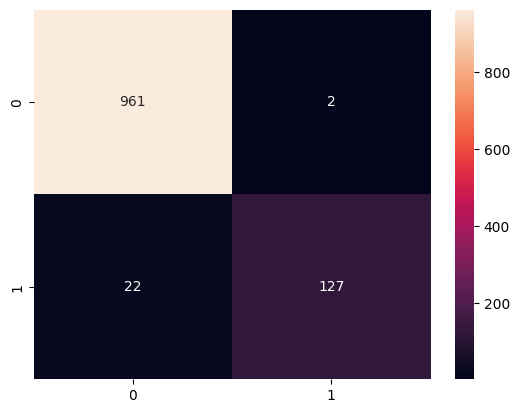

In [21]:
score = accuracy_score(y_test, y_pred)
print("Score: ", score)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.show()

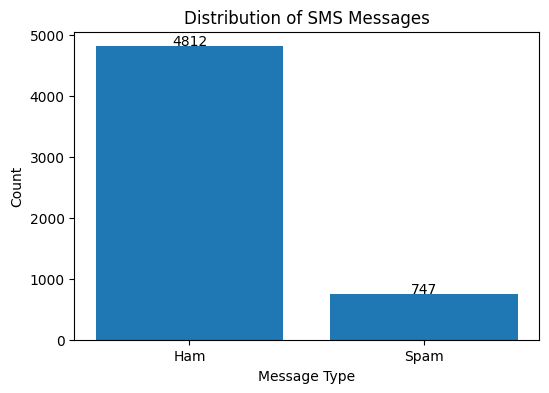

In [22]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt

# Count Spam and Ham messages
class_counts = df['type'].value_counts()

# If labels were converted to numbers
class_counts.index = ['Ham', 'Spam']

# Create bar chart
plt.figure(figsize=(6,4))
plt.bar(class_counts.index, class_counts.values)

plt.title('Distribution of SMS Messages')
plt.xlabel('Message Type')
plt.ylabel('Count')

for i, v in enumerate(class_counts.values):
    plt.text(i, v + 20, str(v), ha='center')

plt.show()

In [27]:
df.loc[:,'type']=df.type.map({'ham':0, 'spam':1})
df['type'] = df['type'].astype(int)
df.head()

,type,text
0,0,Hope you are having a good week. Just checking in
1,0,K..give back my thanks.
2,0,Am also doing in cbe only. But have to pay.
3,1,"complimentary 4 STAR Ibiza Holiday or £10,000 ..."
4,1,okmail: Dear Dave this is your final notice to...


## TRIANING THE MACHINE LEARNING MODEL


###Neural Network

In [34]:
%%time
from sklearn.neural_network import MLPClassifier

mlp_classifier_model = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000)
mlp_classifier_model.fit(X_train, y_train)

prediction = mlp_classifier_model.predict(X_test)

# Calculate and print classification metrics
print("MLP Classifier")
print("Accuracy score: {:.2f}".format(accuracy_score(y_test, prediction)))
print("Precision score: {:.2f}".format(precision_score(y_test, prediction, pos_label='spam')))
print("Recall score: {:.2f}".format(recall_score(y_test, prediction, pos_label='spam')))
print("F1 score: {:.2f}".format(f1_score(y_test, prediction, pos_label='spam')))

MLP Classifier
Accuracy score: 0.98
Precision score: 0.98
Recall score: 0.88
F1 score: 0.93
CPU times: user 1min 8s, sys: 350 ms, total: 1min 8s
Wall time: 41 s


###Multinomial Naive Bayes

In [36]:
%%time
# Multinomial Naive Bayes model
from sklearn.naive_bayes import MultinomialNB

multinomial_nb_model = MultinomialNB()
multinomial_nb_model.fit(X_train, y_train)  # Train the model

prediction = multinomial_nb_model.predict(X_test)

print("Multinomial NB")
print("Accuracy score: {}".format(accuracy_score(y_test, prediction)))
print("Precision score: {}".format(precision_score(y_test, prediction, pos_label='spam')))
print("Recall score: {}".format(recall_score(y_test, prediction, pos_label='spam')))
print("F1 score: {}".format(f1_score(y_test, prediction, pos_label='spam')))

Multinomial NB
Accuracy score: 0.9703237410071942
Precision score: 1.0
Recall score: 0.7785234899328859
F1 score: 0.8754716981132076
CPU times: user 540 ms, sys: 25 µs, total: 540 ms
Wall time: 349 ms


###Bernoulli Naive Bayes

In [38]:
%%time
# Bernoulli Naive Bayes model
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

bernoulli_nb_model = BernoulliNB()
bernoulli_nb_model.fit(X_train, y_train)

prediction = bernoulli_nb_model.predict(X_test)

#Evaluation
print("Bernoulli NB")
print("Accuracy score: {}".format(accuracy_score(y_test, prediction)) )
print("Precision score: {}".format(precision_score(y_test, prediction, pos_label='spam')) )
print("Recall score: {}".format(recall_score(y_test, prediction, pos_label='spam')))
print("F1 score: {}".format(f1_score(y_test, prediction, pos_label='spam')))

Bernoulli NB
Accuracy score: 0.9721223021582733
Precision score: 0.9609375
Recall score: 0.825503355704698
F1 score: 0.8880866425992779
CPU times: user 925 ms, sys: 169 ms, total: 1.09 s
Wall time: 1.06 s


###CONFUSION METRICS

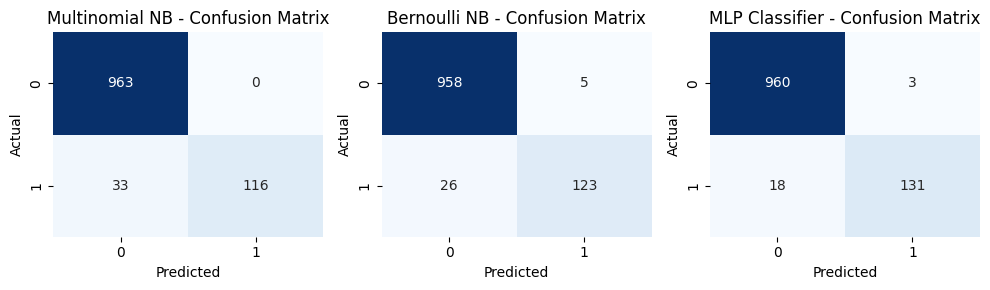

In [39]:
from sklearn.metrics import confusion_matrix
models = [("Multinomial NB", multinomial_nb_model), ("Bernoulli NB", bernoulli_nb_model),("MLP Classifier", mlp_classifier_model) ]

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for i, (model_name, model) in enumerate(models):
    prediction = model.predict(X_test)
    cm = confusion_matrix(y_test, prediction)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[i])
    axes[i].set_title(f"{model_name} - Confusion Matrix")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
plt.tight_layout()
plt.show()

###Metric Comparison Heatmap

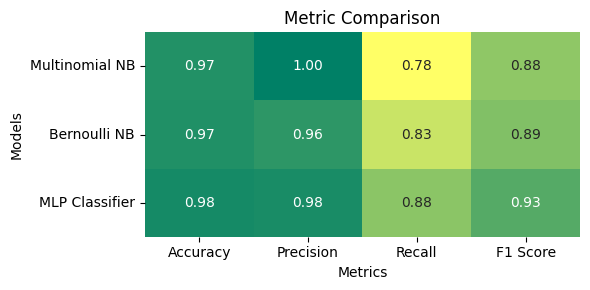

In [41]:
metric_data = []
for model_name, model in models:
    prediction = model.predict(X_test)
    accuracy = accuracy_score(y_test, prediction)
    precision = precision_score(y_test, prediction, pos_label='spam')
    recall = recall_score(y_test, prediction, pos_label='spam')
    f1 = f1_score(y_test, prediction, pos_label='spam')
    metric_data.append([accuracy, precision, recall, f1])
metric_labels = ["Accuracy", "Precision", "Recall", "F1 Score"]
#heatmap for metric comparison
plt.figure(figsize=(6, 3))
sns.heatmap(metric_data, annot=True, fmt=".2f", cbar=False, cmap="summer_r", xticklabels=metric_labels, yticklabels=[model_name for model_name, _ in models])
plt.title("Metric Comparison")
plt.yticks(rotation=0)
plt.xlabel("Metrics")
plt.ylabel("Models")
plt.tight_layout()
plt.show()